# Stage 2 - Unsupervised Clustering
This notebook follows the exact Stage 2 clustering workflow and appends `cluster_id` to engineered feature matrices.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOT_DIR = BASE_DIR / 'outputs' / 'plots' / 'stage2'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(name: str):
    path = PLOT_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')


## Load Stage 1 Outputs
Load engineered train/test matrices and targets from disk.

In [2]:
with open(PROCESSED_DIR / 'stage1_outputs.pkl', 'rb') as f:
    stage1 = pickle.load(f)
X_train_eng = stage1['X_train_eng'].copy()
X_test_eng = stage1['X_test_eng'].copy()
y_train = stage1['y_train'].copy()
borrower_type_train = stage1['borrower_type_train'].copy()
print('Loaded shapes:', X_train_eng.shape, X_test_eng.shape)


Loaded shapes: (8000, 48) (2000, 48)


## Step 1 - Select Clustering Features
Use only the mandated 8 behavioral composite features for clustering.

In [3]:
clustering_features = [
    'utility_payment_ratio', 'rent_consistency_score', 'income_regularity_index',
    'upi_consistency_score', 'digital_footprint_density', 'financial_discipline_score',
    'future_planning_score', 'risk_appetite_score'
]
X_train_clust = X_train_eng[clustering_features].copy()
X_test_clust = X_test_eng[clustering_features].copy()
print('Clustering matrix shapes:', X_train_clust.shape, X_test_clust.shape)
print(X_train_clust.describe().T[['mean', 'std']])


Clustering matrix shapes: (8000, 8) (2000, 8)
                                mean       std
utility_payment_ratio       0.495767  0.275099
rent_consistency_score      0.498747  0.245961
income_regularity_index     0.661435  0.145087
upi_consistency_score       0.200664  0.161085
digital_footprint_density   0.822575  0.332188
financial_discipline_score  0.470059  0.178865
future_planning_score       0.496109  0.191996
risk_appetite_score         0.497625  0.198085


## Step 2 - Determine Optimal K
Evaluate K=2..10 using inertia and silhouette score, then choose K with highest silhouette (tie -> lower K).

K vs silhouette: {2: np.float64(0.2585), 3: np.float64(0.3237), 4: np.float64(0.2417), 5: np.float64(0.2295), 6: np.float64(0.1997), 7: np.float64(0.1872), 8: np.float64(0.1796), 9: np.float64(0.1785), 10: np.float64(0.1725)}
Selected optimal K: 3
Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage2\stage2_elbow_curve.png


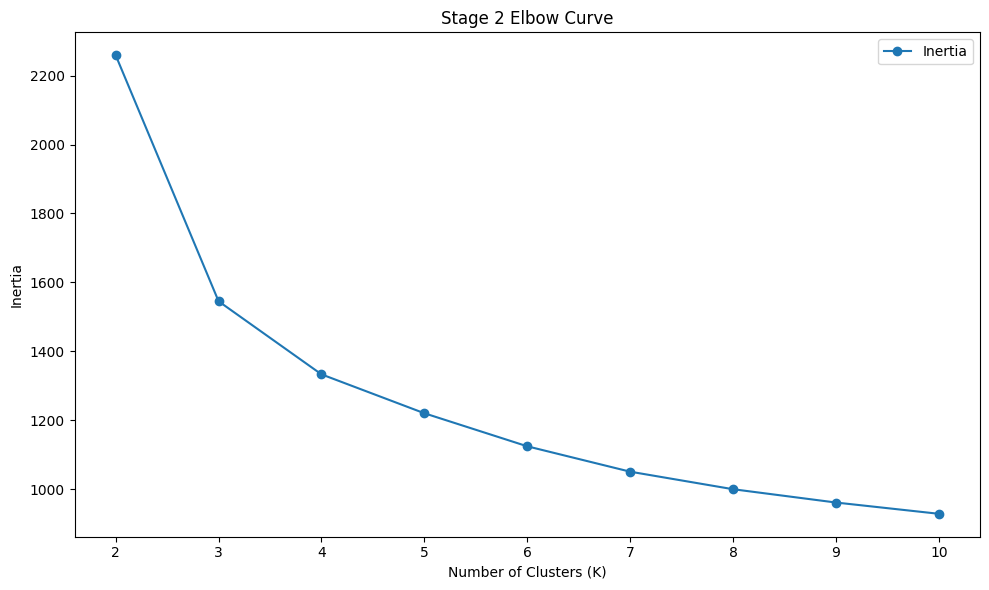

Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage2\stage2_silhouette_curve.png


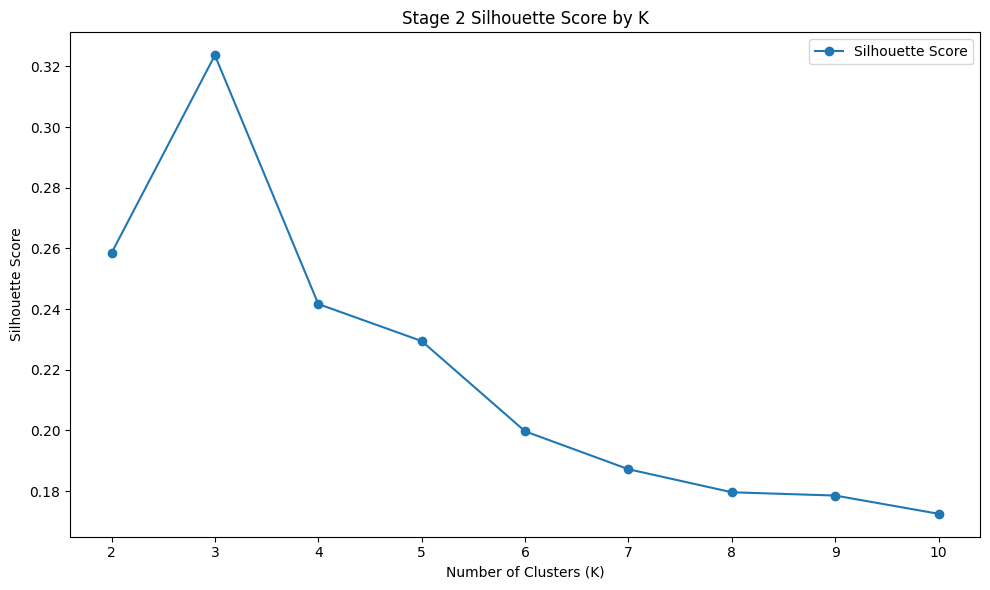

In [4]:
k_values = list(range(2, 11))
inertia_scores = []
sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_train_clust)
    inertia_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_clust, labels))

optimal_k = int(pd.Series(sil_scores, index=k_values).sort_values(ascending=False).index[0])
print('K vs silhouette:', dict(zip(k_values, np.round(sil_scores, 4))))
print('Selected optimal K:', optimal_k)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_scores, marker='o', label='Inertia')
plt.title('Stage 2 Elbow Curve')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
save_plot('stage2_elbow_curve')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(k_values, sil_scores, marker='o', label='Silhouette Score')
plt.title('Stage 2 Silhouette Score by K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
save_plot('stage2_silhouette_curve')
plt.show()


## Step 3 and Step 4 - Fit KMeans and GMM, Compare Silhouette
Train both models at optimal K and keep the one with better silhouette score.

In [5]:
kmeans_model = KMeans(n_clusters=optimal_k, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans_model.fit_predict(X_train_clust)
kmeans_sil = silhouette_score(X_train_clust, kmeans_labels)

gmm_model = GaussianMixture(n_components=optimal_k, random_state=RANDOM_STATE)
gmm_model.fit(X_train_clust)
gmm_labels = gmm_model.predict(X_train_clust)
gmm_sil = silhouette_score(X_train_clust, gmm_labels)

if kmeans_sil >= gmm_sil:
    cluster_model = kmeans_model
    model_name = 'KMeans'
else:
    cluster_model = gmm_model
    model_name = 'GMM'
print(f'KMeans silhouette: {kmeans_sil:.4f} | GMM silhouette: {gmm_sil:.4f}')
print('Selected cluster model:', model_name)


KMeans silhouette: 0.3237 | GMM silhouette: 0.1073
Selected cluster model: KMeans


## Step 5 - Cluster Profiling
Compute per-cluster means of all clustering features and default rate, then assign descriptive profile names.

In [6]:
cluster_train_labels = cluster_model.predict(X_train_clust)
profile_df = X_train_clust.copy()
profile_df['cluster_id'] = cluster_train_labels
profile_df['defaulted'] = y_train.values
cluster_profile_table = profile_df.groupby('cluster_id').mean(numeric_only=True)

cluster_names = {}
for cid, row in cluster_profile_table.iterrows():
    if row['digital_footprint_density'] > cluster_profile_table['digital_footprint_density'].median() and row['financial_discipline_score'] > cluster_profile_table['financial_discipline_score'].median():
        cluster_names[cid] = 'Digitally Active Disciplined'
    elif row['utility_payment_ratio'] > cluster_profile_table['utility_payment_ratio'].median() and row['rent_consistency_score'] > cluster_profile_table['rent_consistency_score'].median():
        cluster_names[cid] = 'Cash-Based Reliable'
    else:
        cluster_names[cid] = 'High-Risk Sparse Data'

cluster_profile_table['cluster_profile_name'] = pd.Series(cluster_names)
print(cluster_profile_table)


            utility_payment_ratio  rent_consistency_score  \
cluster_id                                                  
0                        0.319641                0.357501   
1                        0.712980                0.672620   
2                        0.454065                0.466122   

            income_regularity_index  upi_consistency_score  \
cluster_id                                                   
0                          0.669545               0.102750   
1                          0.668467               0.330876   
2                          0.620243               0.153545   

            digital_footprint_density  financial_discipline_score  \
cluster_id                                                          
0                            0.951015                    0.356306   
1                            0.971103                    0.612668   
2                            0.076183                    0.437260   

            future_planning_score  ri

## Step 6 - Cross-Borrower-Type Check
Check borrower-type concentration per cluster and flag clusters where a single type exceeds 75%.

In [7]:
cross_df = pd.DataFrame({'cluster_id': cluster_train_labels, 'borrower_type': borrower_type_train.values})
cross_tab = pd.crosstab(cross_df['cluster_id'], cross_df['borrower_type'], normalize='index')
print(cross_tab)
for cid in cross_tab.index:
    top_ratio = cross_tab.loc[cid].max()
    top_type = cross_tab.loc[cid].idxmax()
    if top_ratio > 0.75:
        print(f'WARNING: Cluster {cid} is {top_ratio:.2%} {top_type} (>75%).')


borrower_type       gig   migrant     rural
cluster_id                                 
0              0.558243  0.237698  0.204059
1              0.632446  0.230672  0.136882
2              0.000000  0.001604  0.998396


## Step 7 - Assign Cluster Labels
Predict cluster IDs for both train and test sets and add `cluster_id` as an ordinal integer feature.

In [8]:
cluster_train_labels = cluster_model.predict(X_train_clust)
cluster_test_labels = cluster_model.predict(X_test_clust)
X_train_eng['cluster_id'] = cluster_train_labels.astype(int)
X_test_eng['cluster_id'] = cluster_test_labels.astype(int)
print(X_train_eng['cluster_id'].value_counts().sort_index())
print(X_test_eng['cluster_id'].value_counts().sort_index())


cluster_id
0    3597
1    3156
2    1247
Name: count, dtype: int64
cluster_id
0    917
1    790
2    293
Name: count, dtype: int64


## Save Stage 2 Outputs

In [9]:
stage2_output = {
    **stage1,
    'X_train_eng': X_train_eng,
    'X_test_eng': X_test_eng,
    'cluster_model': cluster_model,
    'cluster_profile_table': cluster_profile_table,
    'cluster_names': cluster_names,
    'clustering_features': clustering_features,
    'optimal_k': optimal_k,
    'kmeans_silhouette': kmeans_sil,
    'gmm_silhouette': gmm_sil,
    'selected_cluster_model_name': model_name,
}
out_path = PROCESSED_DIR / 'stage2_outputs.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(stage2_output, f)
print('Saved:', out_path)


Saved: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage2_outputs.pkl


## Stage 2 Summary

In [10]:
print('=' * 70)
print('STAGE 2 SUMMARY')
print('- Completed feature-restricted unsupervised clustering and model comparison.')
print(f"- Optimal K: {optimal_k}")
print(f"- KMeans silhouette: {kmeans_sil:.4f}")
print(f"- GMM silhouette: {gmm_sil:.4f}")
print(f"- Selected cluster model: {model_name}")
print(f"- Added cluster_id to X_train_eng and X_test_eng")
print(f"- Saved outputs to: {out_path}")
print('=' * 70)


STAGE 2 SUMMARY
- Completed feature-restricted unsupervised clustering and model comparison.
- Optimal K: 3
- KMeans silhouette: 0.3237
- GMM silhouette: 0.1073
- Selected cluster model: KMeans
- Added cluster_id to X_train_eng and X_test_eng
- Saved outputs to: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage2_outputs.pkl


In [11]:
inference_s2 = {
    'cluster_model': cluster_model,
    'cluster_profile_table': cluster_profile_table,
    'cluster_names': cluster_names,
    'clustering_features': clustering_features,
    'feature_columns_with_cluster': list(X_train_eng.columns),  # AFTER cluster_id added
}
with open(PROCESSED_DIR / 'inference_artifacts_stage2.pkl', 'wb') as f:
    pickle.dump(inference_s2, f)
